In [1]:
###############################################################
### ASSIGNMENT 1 : PROPAGATION AND PASS PREDICTION
###############################################################


### UNITS AND CONVENTIONS
# All parameters are represented in SI units or otherwise stated.

### CODE USAGE
# In this course you are using actual tracking data from the DopTrack laboratory (https://doptrack.tudelft.nl) and use the Delft-based orbit determination software Tudat
# (https://docs.tudat.space/en/stable/#) to perform orbit analysis.

In [2]:
### IMPORT STATEMEMTS

import sys
sys.path.append("../../")

# Load standard modules
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression  # linear regression module

# Import doptrack-estimate functions
from propagation_functions.environment import *
from propagation_functions.propagation import *
from utility_functions.time import *
from utility_functions.tle import *
from utility_functions.data import extract_tar
from estimation_functions.observations_data import *
from estimation_functions.estimation import *

# Load tudatpy modules
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion, frame_conversion
from tudatpy.dynamics import environment

In [3]:
### EXTRACTING DATA

# Extract data
extract_tar("../metadata.tar.xz")
extract_tar("../data.tar.xz")

# Define import folders
metadata_folder = 'metadata/'
data_folder = 'data/'


### DEFINE INITIAL STATE FROM TLE

# Now that all software is imported, it is time to load in an predetermined initial state of the satellite. Usually, during launch of a new satellites,
# lauchers companies provide a pre-launch TLE. When the satellite is already in orbit (daily) updated TLE's are available. The TLE data is a Two Line Element written
# in ascii format stating the state of the satellite at a certain time. With propagation software an orbit can be propagated from that initial state.
# Here, we extract the initial state from the TLE and not use the proprietary propagator SGP4, but use tudat software to propagate the orbit of the satellite.
# This allows us to fully use all the information in tudat on gravity fields, 3rd bodies, atmospheres, etc.
# Within the DopTrack facility we use a metafile system that is ordered as follows: `nameSat_NORADID_yearmonthdayhourmin.yml`
# In this metafile are the TLE listed that are most up to date for certain passes. You can open the .yml files with a text editor to inspect the structure of the metafile
#  and the contents of it.
# IN THIS BLOCK: you can set the `nb_days_to_propagate` parameter to set the time you want to propagate in the future from the time listed in the TLE.





Satellite TLE Data

In [4]:
# Define initial TLE of Delfi-C3 (used to initialise the CubeSat's orbit)
delfi_tle = environment.Tle("1 32789U 08021G   20092.14603172 +.00001512 +00000-0 +10336-3 0  9992",
                            "2 32789 097.4277 137.6209 0011263 214.0075 146.0432 15.07555919650162")

Epoch
- initial_epoch:
- start_recording_day:
- final_epoch:
- mid_epoch:
- delfi_ephemeris:
- initial_state:

In [5]:
# Retrieve initial epoch from TLE
initial_epoch = delfi_tle.get_epoch()
start_recording_day = get_start_next_day(initial_epoch)

# Define the propagation time, and compute the final and mid-propagation epochs accordingly.
propagation_time = 1.0 * constants.JULIAN_DAY
final_epoch = start_recording_day + propagation_time
mid_epoch = (initial_epoch + final_epoch) / 2.0

# Retrieve the spacecraft's initial state at mid-epoch from the TLE ephemeris
delfi_ephemeris = environment.TleEphemeris("Earth", "J2000", delfi_tle, False)
initial_state = delfi_ephemeris.cartesian_state(mid_epoch)

In [6]:

# DEFINE PROPAGATION ENVIRONMENT

# This function creates a body "Delfi" with the following characteristics.
# The Earth, Sun and Moon are also created, with default settings (gravity field, ephemeris, rotation, etc.)
mass = 2.2
ref_area = (4 * 0.3 * 0.1 + 2 * 0.1 * 0.1) / 4  # Average projection area of a 3U CubeSat
srp_coef = 1.2
drag_coef = 1.2
bodies = define_environment(mass, ref_area, drag_coef, srp_coef, "Delfi")


### DEFINE ACCELERATIONS EXERTED ON DELFI

# The following can be modified. Warning: point_mass_gravity and spherical_harmonic_gravity accelerations should not be active simultaneously for a single body
accelerations = dict(
    Sun={
        'point_mass_gravity': True,
        'solar_radiation_pressure': True
    },
    Moon={
        'point_mass_gravity': True
    },
    Earth={
        'point_mass_gravity': False,
        'spherical_harmonic_gravity': True,
        'drag': True
    },
    Venus={
        'point_mass_gravity': True
    },
    Mars={
        'point_mass_gravity': True
    },
    Jupiter={
        'point_mass_gravity': True
    }
)


In [17]:
### PROPAGATE DYNAMICS OF DELFI

# from initial_epoch to final_epoch, starting from initial_state
# The propagation output is given in cartesian and keplerian states, and the latitude/longitude of the spacecraft are also saved.
cartesian_states, keplerian_states, latitudes, longitudes, saved_accelerations = \
    propagate_initial_state(initial_state, initial_epoch, final_epoch, bodies, accelerations, "Delfi", True)

# Retrieve accelerations
accelerations_to_save, accelerations_ids = retrieve_accelerations_to_save(accelerations, "Delfi")

# Retrieve propagation epochs (in seconds since J2000)
propagation_epochs = cartesian_states[:, 0]

### COMPUTE DIFFERENCE BETWEEN PROPAGATED ORBIT AND REFERENCE TLE EPHEMERIS

rsw_difference_wrt_tle = np.zeros((len(propagation_epochs), 7))
keplerian_difference_wrt_tle = np.zeros((len(propagation_epochs), 7))

# Parse all epochs in propagated state history
for i in range(len(propagation_epochs)):

    current_epoch = propagation_epochs[i]
    rsw_difference_wrt_tle[i,0] = current_epoch
    keplerian_difference_wrt_tle[i,0] = current_epoch

    # Retrieve current TLE and propagated states
    current_tle_state = delfi_ephemeris.cartesian_state(current_epoch)
    current_propagated_state = cartesian_states[i,1:7]

    # Compute difference in the inertial frame
    current_state_difference = current_propagated_state - current_tle_state
    current_position_difference = current_state_difference[0:3]
    current_velocity_difference = current_state_difference[3:6]

    # Compute the rotation matrix from inertial to RSW frames
    rotation_to_rsw = frame_conversion.inertial_to_rsw_rotation_matrix(current_tle_state)

    # Convert the state difference from inertial to RSW frames
    rsw_difference_wrt_tle[i, 1:4] = rotation_to_rsw @ current_position_difference
    rsw_difference_wrt_tle[i, 4:7] = rotation_to_rsw @ current_velocity_difference

    # Compute reference orbital elements from TLE ephemeris
    current_tle_keplerian = element_conversion.cartesian_to_keplerian(current_tle_state, bodies.get("Earth").gravitational_parameter)

    # Compute difference in orbital elements
    keplerian_difference_wrt_tle[i,1:7] = keplerian_states[i,1:7] - current_tle_keplerian



[<tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43CE64F30>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D436C8A4F0>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43B39FEB0>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43CE797F0>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43CE793F0>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43CE9C970>, <tudatpy.kernel.dynamics.propagation_setup.dependent_variable.SingleAccelerationDependentVariableSaveSettings object at 0x000001D43CE9E9B0>, <tudatpy.ker

### PLOTSSSS

#### PLOT PROPAGATED ORBIT

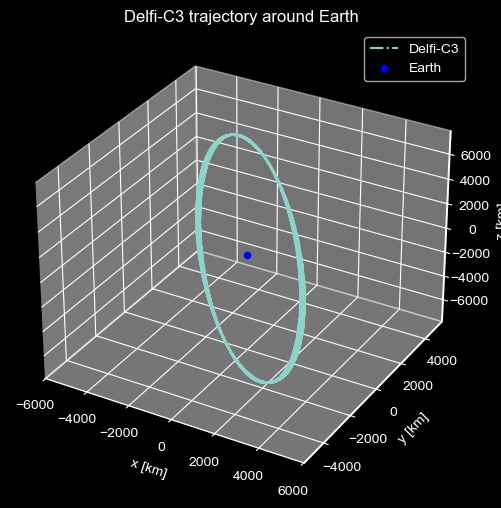

In [8]:
### PLOT PROPAGATED ORBIT
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'Delfi-C3 trajectory around Earth')
ax.plot(cartesian_states[:, 1]/1.0e3, cartesian_states[:, 2]/1.0e3, cartesian_states[:, 3]/1.0e3, label='Delfi-C3', linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Earth", marker='o', color='blue')
ax.legend()
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.set_zlabel('z [km]')
plt.show()



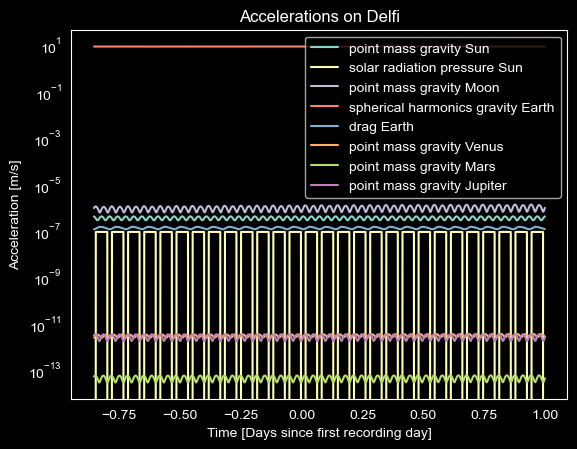

In [9]:
### PLOT ACCELERATIONS ON DELFI
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title(f'Accelerations on Delfi')
for i in range(np.shape(saved_accelerations)[1] - 1):
    ax.plot((saved_accelerations[:, 0] - start_recording_day) / 86400, saved_accelerations[:, i + 1],
            label=accelerations_ids[i], linestyle='-')
ax.legend()
ax.set_xlabel('Time [Days since first recording day]')
ax.set_ylabel('Acceleration [m/s]')
plt.yscale('log')
plt.grid()
plt.show()

#### PLOT - KEPLERIAN ELEMENTS

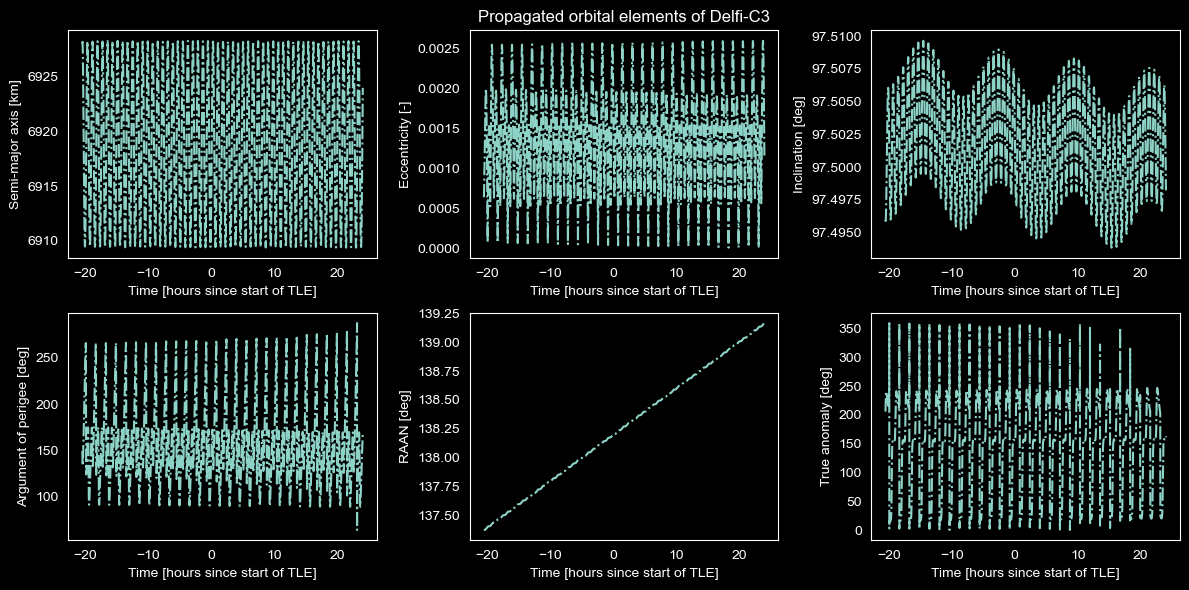

In [10]:
### PLOT KEPLERIAN ELEMENTS OF DELFT'S ORBIT

### Dynamical model: Kepler coordinates
# 3D orbits are nice to look at but do not give a lot of information about the orbit itself. Therefore, normally the orbit can be plotted in its Keplerian coordinates.
# Can you discuss what the orbit of the chosen satellite is doing? What happens if you change the dynamical model by setting the gravitational model of the Earth to a point mass?
# And what happens if you set Drag to `False`? Did you expect this?

fig = plt.figure(figsize=(12,6))

# semi-major axis
ax = fig.add_subplot(231)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, (keplerian_states[:,1])/1.0e3, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Semi-major axis [km]')
ax.grid()

# eccentricity
ax = fig.add_subplot(232)
ax.set_title(f'Propagated orbital elements of Delfi-C3')
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_states[:,2], linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Eccentricity [-]')
ax.grid()

# inclination
ax = fig.add_subplot(233)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_states[:,3]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Inclination [deg]')
ax.grid()

# argument of periapsis
ax = fig.add_subplot(234)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, (keplerian_states[:,4])/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Argument of perigee [deg]')
ax.grid()

# right ascension of the ascending node
ax = fig.add_subplot(235)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_states[:,5]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('RAAN [deg]')
ax.grid()

# true anomaly
ax = fig.add_subplot(236)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_states[:,6]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('True anomaly [deg]')
ax.grid()

fig.tight_layout()

plt.show()


#### PLOT - DIFFERENCES BETWEEN PROPAGATED AND TLE ORBITS IN ORBITAL ELEMENTS

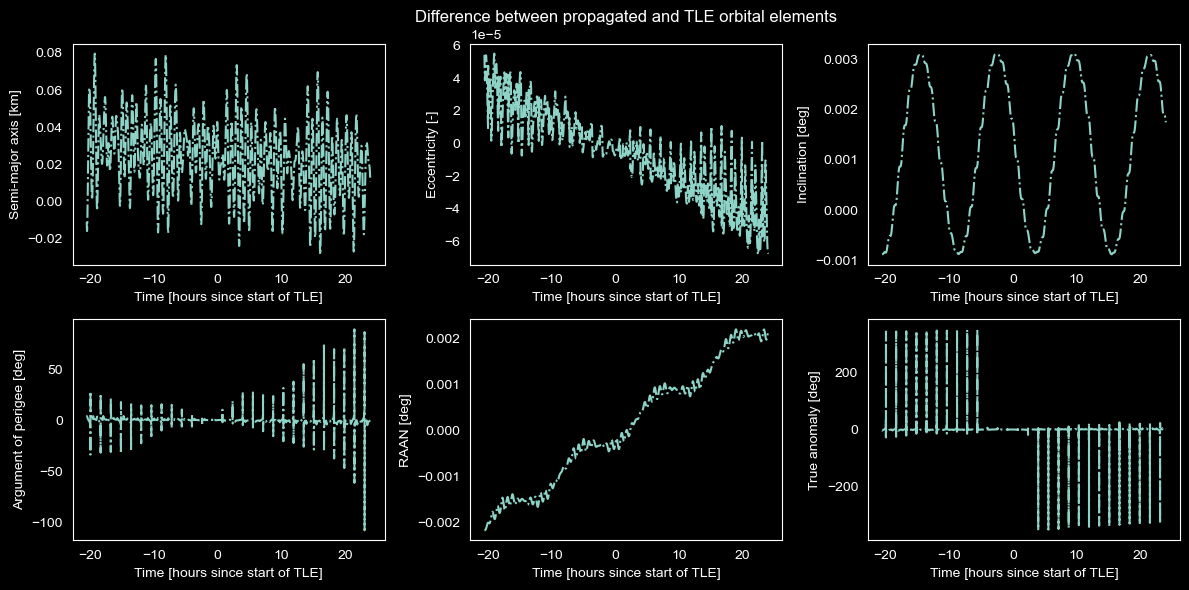

In [11]:
### PLOT DIFFERENCES BETWEEN PROPAGATED AND TLE ORBITS IN ORBITAL ELEMENTS

# The following plots show the difference between Delfi's propagated orbit and its reference ephemeris extrapolated from the initial TLE.
# The differences are expressed in orbital elements and in RSW coordinates (radial, along-track and cross-track positions).
# How do these differences change as you simplify/complexify the dynamical model used to propagate Delfi's orbit?

fig = plt.figure(figsize=(12,6))

# semi-major axis
ax = fig.add_subplot(231)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, (keplerian_difference_wrt_tle[:,1])/1.0e3, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Semi-major axis [km]')
ax.grid()

# eccentricity
ax = fig.add_subplot(232)
ax.set_title(f'Difference between propagated and TLE orbital elements')
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_difference_wrt_tle[:,2], linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Eccentricity [-]')
ax.grid()

# inclination
ax = fig.add_subplot(233)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_difference_wrt_tle[:,3]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Inclination [deg]')
ax.grid()

# argument of periapsis
ax = fig.add_subplot(234)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, (keplerian_difference_wrt_tle[:,4])/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Argument of perigee [deg]')
ax.grid()

# right ascension of the ascending node
ax = fig.add_subplot(235)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_difference_wrt_tle[:,5]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('RAAN [deg]')
ax.grid()

# true anomaly
ax = fig.add_subplot(236)
ax.plot((keplerian_states[:, 0] - start_recording_day)/3600, keplerian_difference_wrt_tle[:,6]/np.pi*180, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('True anomaly [deg]')
ax.grid()

fig.tight_layout()

plt.show()


#### PLOT - DIFFERENCES BETWEEN PROPAGATED AND TLE POSITION IN RSW COORDINATES

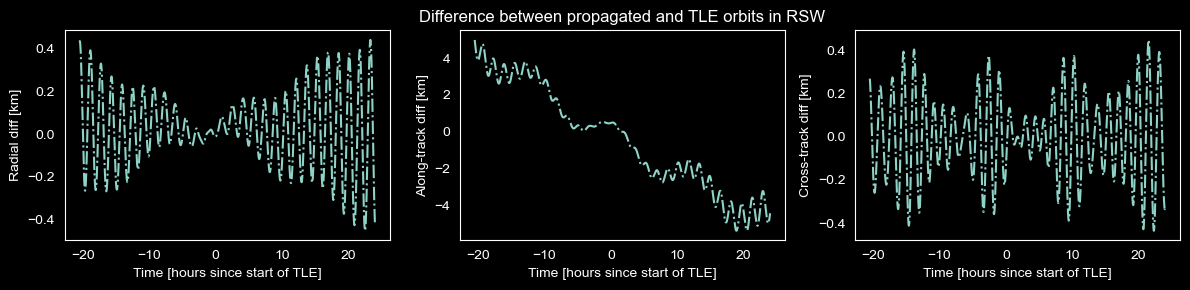

In [12]:
### PLOT DIFFERENCES BETWEEN PROPAGATED AND TLE POSITION IN RSW COORDINATES

# Radial direction
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(131)
ax.plot((propagation_epochs - start_recording_day)/3600, (rsw_difference_wrt_tle[:,1])/1.0e3, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Radial diff [km]')
ax.grid()

# Along-track direction
ax = fig.add_subplot(132)
ax.set_title(f'Difference between propagated and TLE orbits in RSW')
ax.plot((propagation_epochs - start_recording_day)/3600, (rsw_difference_wrt_tle[:,2])/1.0e3, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Along-track diff [km]')
ax.grid()

# Cross-track direction
ax = fig.add_subplot(133)
ax.plot((propagation_epochs - start_recording_day)/3600, (rsw_difference_wrt_tle[:,3])/1.0e3, linestyle='-.')
ax.set_xlabel('Time [hours since start of TLE]')
ax.set_ylabel('Cross-track diff [km]')
ax.grid()

fig.tight_layout()

plt.show()

#### PLOT - GROUND TRACK AND VISIBILITY

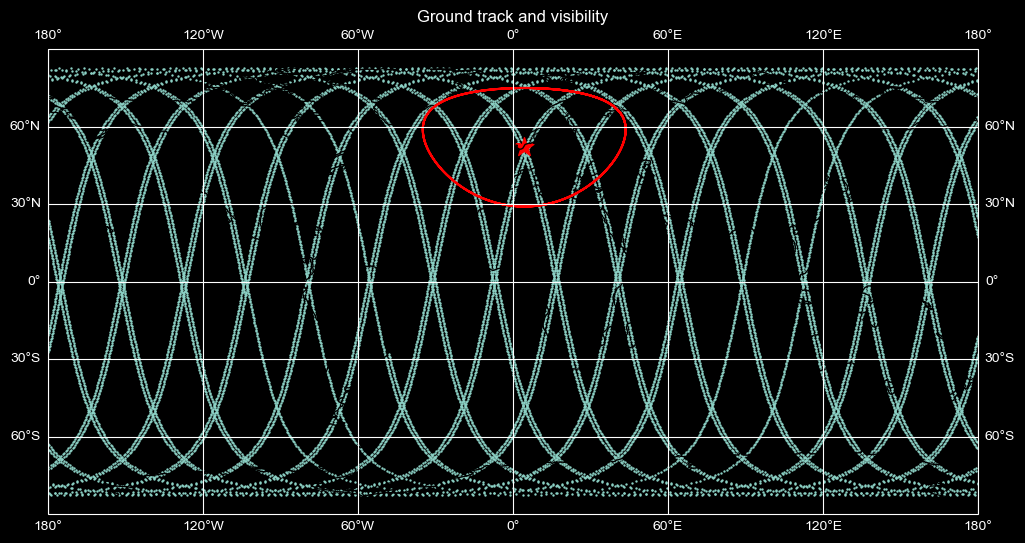

In [13]:
### PASS PREDICTION: GROUND TRACK AND VISIBILITY

# We need to link the orbit prediction to the ground station which is situated on the rotating Earth. We need to know when the satellite is flying over the ground
# station and into the field of view of the station. We need to determine when the satellite passes the horizon. For this we use the predicted orbit and plot the
# ground track with respect to the ground station location and its visibility circle.

location_groundstation_lon = 4.3754
location_groundstation_lat = 51.9899

R = 6371360
h =  547500;
Lambda = np.arccos((R)/(R+h))
Phi_E = np.linspace(0, 2*np.pi, num=1000)

# Create hemisphere function
mask_E = []
for i in range(len(Phi_E)):
    val = (-Phi_E[i]) % 2*np.pi
    if val >= 0 and val < np.pi:
        mask_E.append(1.0)
    else:
        mask_E.append(-1.0)


# Calculate horizon coordinates on the map.
colat_horizon = np.arccos(np.cos(Lambda)*np.cos((90-location_groundstation_lat)/180*np.pi)+np.sin(Lambda)*np.sin((90-location_groundstation_lat)/180*np.pi)*np.cos(Phi_E % 2*np.pi))
DL = ((mask_E * np.arccos((np.cos(Lambda)-np.cos(colat_horizon)*np.cos((90-location_groundstation_lat)/180*np.pi))/(np.sin((90-location_groundstation_lat)/180*np.pi)*np.sin(colat_horizon)))))

latitude_horizon = (90-(colat_horizon/np.pi*180))
longitude_horizon_abs = ((location_groundstation_lon/180*np.pi-DL)/np.pi*180)
longitude_horizon = np.where(longitude_horizon_abs <= 180, longitude_horizon_abs, longitude_horizon_abs - 360)

# Plot groundtrack with visibility area of ground station
plt.figure(figsize = (12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.scatter(longitudes/np.pi*180, latitudes/np.pi*180, label='Delfi-C3', marker='.',s=2)
ax.scatter(location_groundstation_lon,location_groundstation_lat, color='red', marker='*',s=200)
ax.plot(longitude_horizon,latitude_horizon,color ='red')
ax.gridlines(draw_labels=True)
plt.title('Ground track and visibility')
plt.show()

#### PLOT - ELEVATION AND AZIMUTH OF THE PASSES


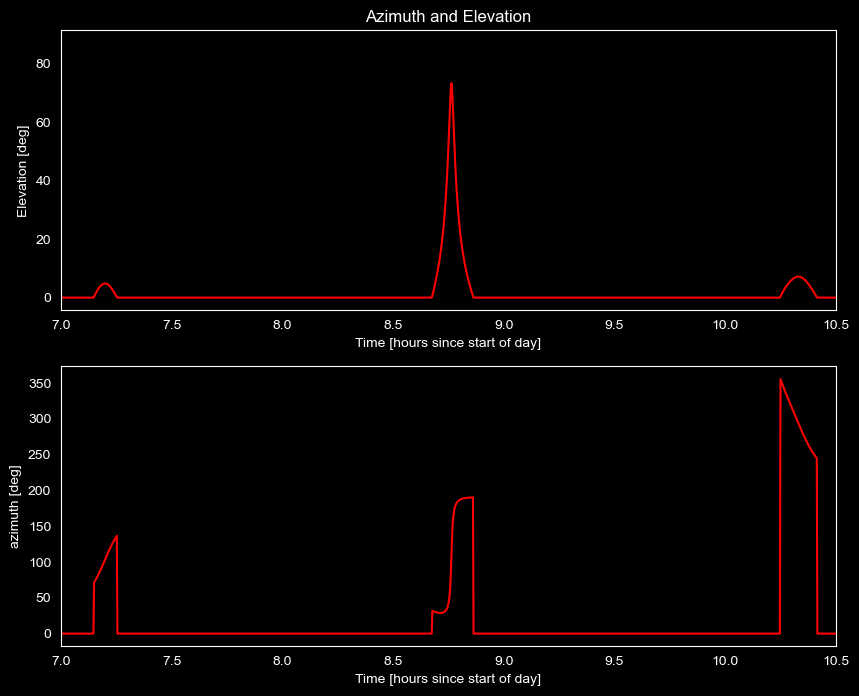

In [14]:
### ELEVATION AND AZIMUTH OF THE PASSES

sin_rho = R/(R+h)
DL_e = np.deg2rad(np.rad2deg(longitudes[:,1])-location_groundstation_lon)
Lambda_e = np.arccos(np.cos(latitudes[:,1])*np.cos(np.deg2rad(location_groundstation_lat))+np.sin(latitudes[:,1])*np.sin(np.deg2rad(location_groundstation_lat))*np.cos(DL_e))

# Calculate elevation
eta = np.arctan2(sin_rho*np.sin(Lambda_e),1-sin_rho*np.cos(Lambda_e))
elevation_abs = np.rad2deg(np.arccos(np.sin(eta)/sin_rho))
elevation_lambda_check = np.where(Lambda_e <= np.arccos(R/(R+h)), elevation_abs, 0)
elevation = np.where(np.abs(DL_e)<= 0.5*np.pi, elevation_lambda_check, 0)

# Plot elevation
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(211)
ax.set_title(f'Azimuth and Elevation')
ax.plot((longitudes[:,0] - start_recording_day)/3600, elevation, color='red')
ax.set_xlim(7.0, 10.5)
ax.set_xlabel('Time [hours since start of day]')
ax.set_ylabel('Elevation [deg]')
plt.grid()


# Calculate azimuth

# Create hemisphere function
mask_DL = []
for i in range(len(DL_e)):
    val = (DL_e[i]) % 2*np.pi
    if val >= 0 and val < np.pi:
        mask_DL.append(1.0)
    else:
        mask_DL.append(-1.0)

azimuth_abs = np.rad2deg(mask_DL*np.arccos((np.cos(np.deg2rad(location_groundstation_lat))-np.cos(latitudes[:,1])*np.cos(Lambda_e))/(np.sin(latitudes[:,1])*np.sin(Lambda_e))))
azimuth_lambda_check = np.where(Lambda_e <= np.arccos(R/(R+h)), azimuth_abs, 0)
azimuth = np.where(np.abs(DL_e)<= 0.5*np.pi, azimuth_lambda_check, 0)


# Plot azimuth
ax = fig.add_subplot(212)
ax.plot((longitudes[:,0] - start_recording_day)/3600, azimuth % 360, color='red')
ax.set_xlim(7.0, 10.5)
ax.set_xlabel('Time [hours since start of day]')
ax.set_ylabel('azimuth [deg]')
plt.grid()
plt.show()

###  SIMULATE DOPPLER MEASUREMENTS

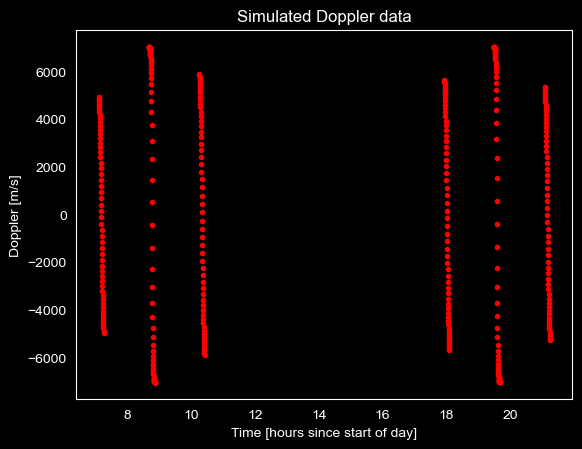

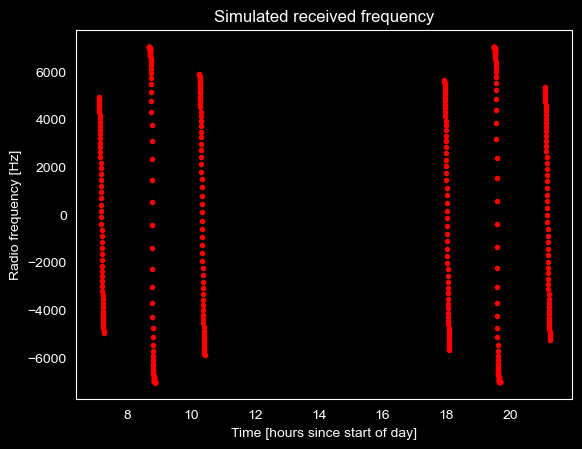

In [15]:
### SIMULATE DOPPLER MEASUREMENTS

# The predicted orbit and visibility information is used to simulate range-rate observations at the times of the predicted pass of the satellite over Delft. With the (simplified)
# Doppler equation, the received radio frequency can be calculated from the simulated range-rate.

# Create the DopTrack station
define_doptrack_station(bodies)

# Define observation settings
observation_settings = define_ideal_doppler_settings(["DopTrackStation"], "Delfi")

# Create list of observation times, with one Doppler measurement every 10 seconds
possible_obs_times = []
obs_time_step = 10.0
current_time = start_recording_day
while current_time < final_epoch:
    possible_obs_times.append(current_time)
    current_time = current_time + obs_time_step

# Simulate (ideal) observations
propagator_settings = create_propagator_settings(initial_state, initial_epoch, final_epoch, bodies, accelerations, "Delfi")
simulated_observations = simulate_observations("Delfi", possible_obs_times, observation_settings, propagator_settings, bodies, initial_epoch, 0)

simulated_obs_times = np.array(simulated_observations.concatenated_times)
simulated_doppler = simulated_observations.concatenated_observations


# Plot simulated Doppler data
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title(f'Simulated Doppler data')
ax.plot((simulated_obs_times - start_recording_day)/3600, simulated_doppler, color='red', linestyle='none', marker='.')
ax.set_xlabel('Time [hours since start of day]')
ax.set_ylabel('Doppler [m/s]')
plt.grid()
plt.show()


# With simplified doppler formula, calculate received frequency
satellite_frequency = 145870000
speed_of_light = 299792458

frequency_received = (1-simulated_doppler/speed_of_light)*satellite_frequency

# Plot simulated frequency data
fig = plt.figure()
ax = fig.add_subplot()
ax.set_title(f'Simulated received frequency')
ax.plot((simulated_obs_times - start_recording_day)/3600, simulated_doppler, color='red', linestyle='none', marker='.')
ax.set_xlabel('Time [hours since start of day]')
ax.set_ylabel('Radio frequency [Hz]')
plt.grid()
plt.show()


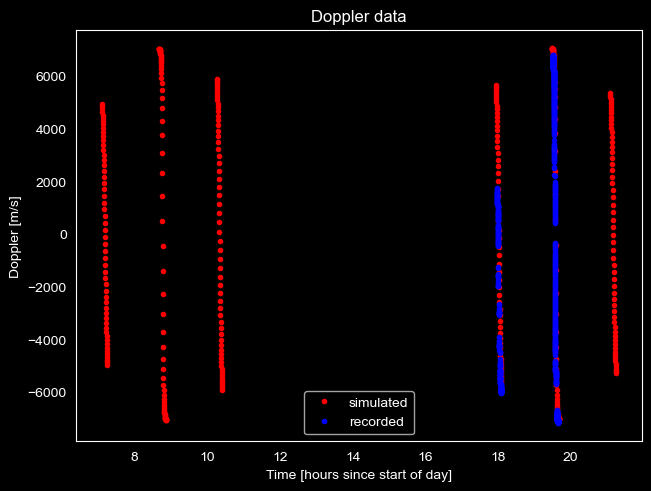

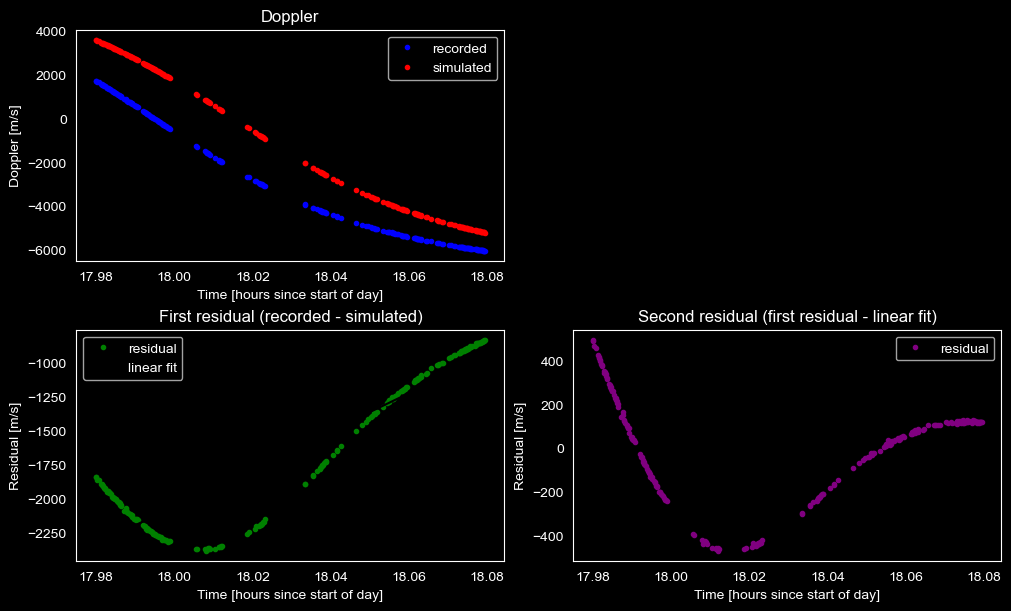

In [16]:


###############################################################
### STEP 3. LOAD REAL OBSERVATIONS
###############################################################


# During your visit at the DopTrack facility, you have recorded your own frequency passes and the automated processor has converted the frequency measurements into range-rate data.
# The Doppler Tracking experiment (DopTrack) uses communication signals to generate observables of satellites.
#
# Due to the Doppler effect satellite communication signals have a distinct S-shape in the frequency domain. The Doppler effect tells us that an observer can perceive the frequency
# of a transmitted signal differently if there are changes in the distance between the observer and transmitter. The first order approximation of this frequency change can be e
# xpressed as follows:
# f_station =( 1 - Delta_v /c ) * f0
# The transmitted frequency, f0, is changed by the relative velocity between the transmitting satellite and the receiver in the ground station, Delta_v = v_s - v_r.
# The speed of light is represented by c. In this way, you are able to calculate the received frequency, f_station. Of course, in satellite tracking, we are interested
# in the line-of-sight velocity, Delta_v, which is called range-rate.
# So, by measuring the observed frequency on the ground, we are able to obtain the range-rate observable for the transmitting satellite. This is what you will(/have) record(ed)
# at the DopTrack facility.
#
# Now it is your time to look at the data recorded and how well they are related to the simulated observations. Default code uses Delfi-C3 data sets that are linked to the .yml file
# used in the propagation part of this notebook.


# Observation files to be uploaded
metadata = ['Delfi-C3_32789_202004021953.yml', 'Delfi-C3_32789_202004022126.yml']
data = ['Delfi-C3_32789_202004021953.csv', 'Delfi-C3_32789_202004022126.csv']

# Compute recording start times
recording_start_times = extract_recording_start_times_yml(metadata_folder, metadata, old_yml=False)

# Process observations.
# This loads the recorded observations and retrieve the start of each tracking pass
passes_start_times, passes_end_times, observation_times, observations_set = load_and_format_observations(
    "Delfi", data_folder, data, recording_start_times, old_obs_format=False)

# Retrieve measured Doppler values
real_doppler = observations_set.concatenated_observations


# Plot simulated vs. real Doppler
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot()
ax.set_title(f'Doppler data')
ax.plot((np.array(simulated_obs_times) - start_recording_day)/3600, simulated_doppler, label='simulated', color='red', linestyle='none', marker='.')
ax.plot((np.array(observation_times) - start_recording_day)/3600, real_doppler, label='recorded', color='blue', linestyle='none', marker='.')
ax.legend()
ax.set_xlabel('Time [hours since start of day]')
ax.set_ylabel('Doppler [m/s]')
plt.grid()
plt.show()


###############################################################
### STEP 4. COMPARE SIMULATED AND RECORDED DATA FOR SINGLE PASS
###############################################################

# From the previous figure it seems that the predicted model is able to capture the observed data quite accurate. To determine how accurate we select a single pass
# with `index_pass` parameter and inspect this data.
# In the DopTrack terminology, the difference between the observed range-rate and the predicted range-rate is called the first residual.
# Index of the *recorded* pass of interest (warning: the number of recorded passes might differ from the number of simulated passes)

index_pass = 0
single_pass_start_time = passes_start_times[index_pass]
single_pass_end_time = passes_end_times[index_pass]

# Retrieve recorded Doppler data for single pass
real_obs_single_pass = get_observations_single_pass(single_pass_start_time, single_pass_end_time, observations_set)

# Retrieve simulated Doppler data for single pass
simulated_obs_single_pass = get_observations_single_pass(single_pass_start_time, single_pass_end_time, simulated_observations)

# Interpolate simulated and recorded observations to identical times
interpolated_simulated_obs, interpolated_real_obs = interpolate_obs(simulated_obs_single_pass, real_obs_single_pass)
interpolated_times = interpolated_simulated_obs[:,0]

# Compute first residual between recorded and simulated observations
first_residual_obs = interpolated_real_obs[:,1] - interpolated_simulated_obs[:,1]


### REMOVE LINEAR DRIFT FROM DOPPLER DATA

# Over time we have found that in the Delfi-C3 data there is in many passes a linear drift in the frequency data, with respect to the predicted range-rate. We hypothesised that
# there is a linear drift in the onboard oscillator or an other system that is responsible for a linear drift in the transmitted frequency. As a first data anaylysis, a linear drift
# is fitted through the first residual. The resulting residual is called the second residual, which should be free of any onboard clock drifts.
# Some background: To test this hypothesis we have observed over the years different satellites. One of them is the Nayif-1, which has a much better onboard clock and radio, less
# affected by drifts. We have found that the Nayif-1 data has better quality and is less pronounced by clock drift. This partly confirms our hypothesis, but much is still unclear
# and need to be studied.

# Perform linear regression on first residual
linear_fit = LinearRegression().fit(interpolated_times.reshape((-1, 1)), first_residual_obs)

# Retrieve fit model
fit = linear_fit.predict(np.linspace(interpolated_times[0], interpolated_times[len(interpolated_times)-1]).reshape((-1, 1)))

# Compute second residual after removing linear fit
second_residual_obs = first_residual_obs - linear_fit.predict(interpolated_times.reshape((-1, 1)))


### PLOT SINGLE PASS OBSERVATIONS
# (both recorded and simulated, as well as first and second residuals)

fig = plt.figure(figsize=(10,6), constrained_layout=True)

ax1 = fig.add_subplot(2,2,1)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.plot((interpolated_times - start_recording_day)/3600, interpolated_real_obs[:,1], label='recorded', color='blue', linestyle='none', marker='.')
ax1.plot((interpolated_times - start_recording_day)/3600, interpolated_simulated_obs[:,1], label='simulated', color='red', linestyle='none', marker='.')
ax1.grid()
ax1.set_title(f'Doppler')
ax1.legend()
ax1.set_xlabel('Time [hours since start of day]')
ax1.set_ylabel('Doppler [m/s]')

ax3.plot((interpolated_times - start_recording_day)/3600, first_residual_obs, label='residual', color='green', linestyle='none', marker='.')
ax3.plot((np.linspace(interpolated_times[0], interpolated_times[len(interpolated_times)-1]) - start_recording_day)/3600, fit, label='linear fit', color='black', linestyle='-')
ax3.grid()
ax3.set_title(f'First residual (recorded - simulated)')
ax3.legend()
ax3.set_xlabel('Time [hours since start of day]')
ax3.set_ylabel('Residual [m/s]')

ax4.plot((interpolated_times - start_recording_day)/3600, second_residual_obs, label='residual', color='purple', linestyle='none', marker='.')
ax4.grid()
ax4.set_title(f'Second residual (first residual - linear fit)')
ax4.legend()
ax4.set_xlabel('Time [hours since start of day]')
ax4.set_ylabel('Residual [m/s]')


plt.show()